In [121]:
import sys
from pathlib import Path

project_root = Path.cwd().parents[1]  # importing functions from other folders

sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os
from _data.data_utils import read_in
from _fitting.fitting_utils import abbrev_stat
from _fitting.model_utils_smooth import *
# from _fitting.fitting_utils import hist_plot, CI_plot, CI_plot_alt, CI_plot_both, plot_posteriors_side_by_side, plot_spline_Bknots
import pymc as pm
import pymc.math as pmm
import arviz as az
from patsy import dmatrix
import nutpie
import time
from IPython.display import display
from pymc.variational.callbacks import CheckParametersConvergence
import io
import base64
import re
import pytensor.tensor as pt
from pytensor.gradient import disconnected_grad
from scipy.sparse.linalg import eigsh
from matplotlib.colors import Normalize, TwoSlopeNorm, to_rgba

az.style.use("arviz-darkgrid")

if '___laptop' in os.listdir('../../'):

    # laptop folder
    folder = "../../../_data/p-dengue/"
elif '___server' in os.listdir('../../'):

    # server folder
    folder = "../../../../../../data/lucaratzinger_data/p_dengue/"

%matplotlib inline
import seaborn as sns

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

###
from _fitting.model_utils import data_settings_to_name
###

In [122]:
def parse_name(name):
        p_match = re.search(r'p=([\d.]+)', name)
        k_match = re.search(r'__knots\((\d+)', name)
        # s_match = re.search(r'std=(True|False)', name)
        stat_match = re.search(r'\[([a-zA-Z0-9_()]+)\]', name)
        return {
            'p': float(p_match.group(1)) if p_match else None,
            'num_knots': int(k_match.group(1)) if k_match else None,
            # 'std': s_match.group(1) == 'True' if s_match else None,
            'stat_name': stat_match.group(1) if stat_match else None,
        }

In [123]:
data_settings = {'admin':2, 'max_lag':6, 'start_year':2016, 'start_month':1, 'end_year':2019, 'end_month':12,
                 'select_admin1_regions':regions}
data_name = data_settings_to_name(data_settings)

fitting_task = '20_smooth_exact_simple_adjusted_greedy_6'

_data = read_in(folder, **data_settings, standardise=True, dropna=True, celsius=True, tp_log=True)
statistics = _data.columns.tolist()
# that start with t2m, rh, tp
statistics = [name for name in statistics if name.startswith(('t2m','rh','tp'))]
# that contains 'pop_weighted'
statistics = [name for name in statistics if 'pop_weighted' in name]
# if it contains 'tp' then it should contain 'log('
statistics = [name for name in statistics if not (name.startswith('tp') and 'log(' not in name)]
lags = [0, 1, 2, 3, 4, 5, 6]
statistics = [stat for stat in statistics if any(f"({lag})" in stat for lag in lags)]

In [124]:
df = _data.copy()

# Define bin edges (0 → max population, step = 500k)
bin_width = 500_000
bins = np.arange(0, df['population'].max() + bin_width, bin_width)

# Assign each row to a population bin
df['pop_bin'] = pd.cut(df['population'], bins=bins)

# Group and compute variance
agg = (
    df.groupby('pop_bin')
      .agg(
          n=('population', 'size'),
          pop_mean=('population', 'mean'),
          cases_var=('cases', 'var'),
          rate_var=('rate', 'var')
      )
      .reset_index()
)

print(agg)

                  pop_bin     n      pop_mean     cases_var      rate_var
0         (0.0, 500000.0]   868  2.915069e+05   2724.862898  1.569999e-08
1   (500000.0, 1000000.0]  1503  7.620472e+05   5272.764273  1.285571e-08
2  (1000000.0, 1500000.0]  1782  1.222316e+06   1711.020524  1.190453e-09
3  (1500000.0, 2000000.0]   666  1.681792e+06   2993.332295  9.871282e-10
4  (2000000.0, 2500000.0]   456  2.190560e+06  10032.159225  1.994660e-09
5  (2500000.0, 3000000.0]   477  2.770927e+06  15805.979229  2.003869e-09
6  (3000000.0, 3500000.0]   131  3.116393e+06  26596.539284  2.736534e-09
7  (3500000.0, 4000000.0]   132  3.748189e+06  40037.500983  2.783374e-09
8  (4500000.0, 5000000.0]    48  4.681663e+06  31014.290780  1.444501e-09


In [125]:
np.e**(-20)*1e9/2

1.03057681121928

<BarContainer object of 9 artists>

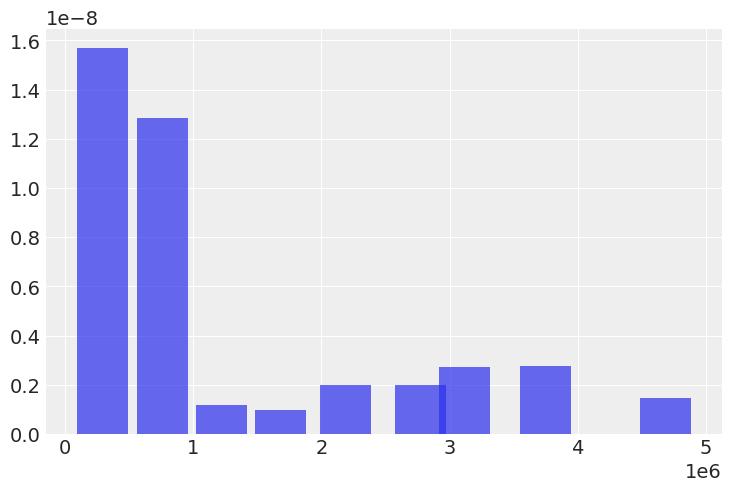

In [126]:
plt.bar(agg['pop_mean'], agg['rate_var'], width=bin_width*0.8, alpha=0.7, label='Cases Variance')

In [127]:
_data

,admin1,admin2,year,month,cases,ONI,t2m_mean_unweighted(0),t2m_mean_pop_weighted(0),t2m_min_unweighted(0),t2m_min_pop_weighted(0),...,urban_surveillance_pop_weighted,density_unweighted,density_pop_weighted,urban_density_unweighted,urban_density_pop_weighted,urbanisation_nonweighted_std,urbanisation_pop_weighted_std,ONI_std,date,rate
0,BALI,BADUNG,2016,1,99.0,2.48,25.95434,26.686537,23.34800,24.112500,...,0.977009,846.953688,9196.723185,1122.493225,10246.088455,0.038556,0.109799,3.171392,2016-01-01,0.000200
1,BALI,BADUNG,2016,2,270.0,2.14,25.25274,25.920562,23.24032,23.918697,...,0.977009,846.953688,9196.723185,1122.493225,10246.088455,0.038556,0.109799,2.708052,2016-02-01,0.000547
2,BALI,BADUNG,2016,3,560.0,1.58,26.15292,26.888789,23.65035,24.383227,...,0.977009,846.953688,9196.723185,1122.493225,10246.088455,0.038556,0.109799,1.944904,2016-03-01,0.001134
3,BALI,BADUNG,2016,4,796.0,0.94,26.24926,27.041781,23.85190,24.615621,...,0.977009,846.953688,9196.723185,1122.493225,10246.088455,0.038556,0.109799,1.072736,2016-04-01,0.001612
4,BALI,BADUNG,2016,5,575.0,0.39,26.02560,26.723972,23.08047,23.707601,...,0.977009,846.953688,9196.723185,1122.493225,10246.088455,0.038556,0.109799,0.323215,2016-05-01,0.001165
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6058,JAWA TENGAH,WONOSOBO,2019,8,2.0,0.14,21.09677,20.562051,13.38350,12.970517,...,0.902731,648.843726,6510.431656,998.983508,7535.435480,-0.425267,-0.221768,-0.017476,2019-08-01,0.000002
6059,JAWA TENGAH,WONOSOBO,2019,9,4.0,0.19,21.84347,21.325349,14.62066,14.213998,...,0.902731,648.843726,6510.431656,998.983508,7535.435480,-0.425267,-0.221768,0.050663,2019-09-01,0.000005
6060,JAWA TENGAH,WONOSOBO,2019,10,0.0,0.35,22.50854,21.855492,16.92578,16.193854,...,0.902731,648.843726,6510.431656,998.983508,7535.435480,-0.425267,-0.221768,0.268705,2019-10-01,0.000000
6061,JAWA TENGAH,WONOSOBO,2019,11,0.0,0.51,22.41485,21.668471,17.74460,17.032770,...,0.902731,648.843726,6510.431656,998.983508,7535.435480,-0.425267,-0.221768,0.486747,2019-11-01,0.000000


In [ ]:
_data

In [100]:
regions = [#'ACEH',
           #'SUMATRA BARAT',
           #'NUSA TENGGARA TIMUR',
           #'SUMATRA UTARA',
           #'PAPUA SELATAN',
           'BALI',
           #'KALIMANTAN SELATAN',
           'JAWA BARAT',
           #'SULAWESI TENGAH',
           #'KEPULAUAN BANGKA BELITUNG',
           'JAWA TIMUR',
           'JAWA TENGAH',
           #'SULAWESI SELATAN',
           'DAERAH ISTIMEWA YOGYAKARTA',
           #'SUMATRA SELATAN',
           #'KALIMANTAN TENGAH',
           #'JAMBI',
           #'RIAU',
           #'KALIMANTAN BARAT',
           #'BENGKULU',
           #'KALIMANTAN TIMUR',
           #'PAPUA',
           #'NUSA TENGGARA BARAT', 
           #'KEPULAUAN RIAU', 
           #'GORONTALO',
           #'SULAWESI UTARA',
           #'SULAWESI TENGGARA',
           #'KALIMANTAN UTARA',
           #'MALUKU',
           #'PAPUA TENGAH',
           #'PAPUA BARAT',
           #'MALUKU UTARA',
           #'PAPUA PEGUNUNGAN',
           #'LAMPUNG',
           'BANTEN',
           'DKI JAKARTA',
           #'PAPUA BARAT DAYA',
           #'SULAWESI BARAT'

]

In [98]:
_data['admin1'].unique()

array(['ACEH', 'SUMATRA BARAT', 'NUSA TENGGARA TIMUR', 'SUMATRA UTARA',
       'PAPUA SELATAN', 'BALI', 'KALIMANTAN SELATAN', 'JAWA BARAT',
       'SULAWESI TENGAH', 'KEPULAUAN BANGKA BELITUNG', 'JAWA TIMUR',
       'JAWA TENGAH', 'SULAWESI SELATAN', 'DAERAH ISTIMEWA YOGYAKARTA',
       'SUMATRA SELATAN', 'KALIMANTAN TENGAH', 'JAMBI', 'RIAU',
       'KALIMANTAN BARAT', 'BENGKULU', 'KALIMANTAN TIMUR', 'PAPUA',
       'NUSA TENGGARA BARAT', 'KEPULAUAN RIAU', 'GORONTALO',
       'SULAWESI UTARA', 'SULAWESI TENGGARA', 'KALIMANTAN UTARA',
       'MALUKU', 'PAPUA TENGAH', 'PAPUA BARAT', 'MALUKU UTARA',
       'PAPUA PEGUNUNGAN', 'LAMPUNG', 'BANTEN', 'DKI JAKARTA',
       'PAPUA BARAT DAYA', 'SULAWESI BARAT'], dtype=object)

In [4]:
selected_complete_simple = { # adjusted for pareto k and sampling
    'rh_mean_pop_weighted(0)': [(2.5, 5)],
    'rh_mean_pop_weighted(1)': [(2.5, 5)],
    'rh_mean_pop_weighted(2)': [(2.5, 5)],
    'rh_mean_pop_weighted(3)': [(2.5, 5)],
    'rh_mean_pop_weighted(4)': [(2.5, 5)],
    'rh_mean_pop_weighted(5)': [(2.5, 5)],
    'rh_mean_pop_weighted(6)': [(2.5, 5)],
    ###
    't2m_max_pop_weighted(0)': [(2.5, 20)],
    't2m_max_pop_weighted(1)': [(2.5, 20)],
    't2m_max_pop_weighted(2)': [(2.5, 20)],
    't2m_max_pop_weighted(3)': [(2.5, 20)],
    't2m_max_pop_weighted(4)': [(2.5, 20)],
    't2m_max_pop_weighted(5)': [(2.5, 20)],
    't2m_max_pop_weighted(6)': [(2.5, 20)],
    ###
    't2m_mean_pop_weighted(0)': [(5.0, 10)],
    't2m_mean_pop_weighted(1)': [(5.0, 10)],
    't2m_mean_pop_weighted(2)': [(5.0, 10)],
    't2m_mean_pop_weighted(3)': [(5.0, 10)],
    't2m_mean_pop_weighted(4)': [(5.0, 10)],
    't2m_mean_pop_weighted(5)': [(5.0, 10)],
    't2m_mean_pop_weighted(6)': [(5.0, 10)],
    ###
    't2m_min_pop_weighted(0)': [(2.5, 20)],
    't2m_min_pop_weighted(1)': [(2.5, 20)],
    't2m_min_pop_weighted(2)': [(2.5, 20)],
    't2m_min_pop_weighted(3)': [(2.5, 20)],
    't2m_min_pop_weighted(4)': [(2.5, 20)],
    't2m_min_pop_weighted(5)': [(2.5, 20)],
    't2m_min_pop_weighted(6)': [(2.5, 20)],
    ###
    'tp_24hmax_pop_weighted_log(0)': [(2.5, 5)],
    'tp_24hmax_pop_weighted_log(1)': [(2.5, 5)],
    'tp_24hmax_pop_weighted_log(2)': [(2.5, 5)],
    'tp_24hmax_pop_weighted_log(3)': [(2.5, 5)],
    'tp_24hmax_pop_weighted_log(4)': [(2.5, 5)],
    'tp_24hmax_pop_weighted_log(5)': [(2.5, 5)],
    'tp_24hmax_pop_weighted_log(6)': [(2.5, 5)],
    ###
    'tp_24hmean_pop_weighted_log(0)': [(2.5, 5)],
    'tp_24hmean_pop_weighted_log(1)': [(2.5, 5)],
    'tp_24hmean_pop_weighted_log(2)': [(2.5, 5)],
    'tp_24hmean_pop_weighted_log(3)': [(2.5, 5)],
    'tp_24hmean_pop_weighted_log(4)': [(2.5, 5)],
    'tp_24hmean_pop_weighted_log(5)': [(2.5, 5)],
    'tp_24hmean_pop_weighted_log(6)': [(2.5, 5)],
}

p = {s: vals[0][0] for s, vals in selected_complete_simple.items()}
num_knots = {s: vals[0][1] for s, vals in selected_complete_simple.items()}

In [5]:
s1_list = []

# greedy_1

# greedy_2
# s1_list.append(['tp_24hmean_pop_weighted_log(1)']) #1
# s1_list.append(['rh_mean_pop_weighted(1)']) #2
# s1_list.append(['rh_mean_pop_weighted(0)']) #3

# greedy_3
# s1_list.append(['tp_24hmean_pop_weighted_log(1)', 't2m_max_pop_weighted(4)']) #1
# s1_list.append(['tp_24hmean_pop_weighted_log(1)', 't2m_mean_pop_weighted(4)']) #2
# s1_list.append(['rh_mean_pop_weighted(1)', 'tp_24hmean_pop_weighted_log(5)']) #3

# greedy_4
# s1_list.append(['rh_mean_pop_weighted(1)', 'tp_24hmean_pop_weighted_log(5)', 't2m_max_pop_weighted(6)']) #1
# s1_list.append(['rh_mean_pop_weighted(1)', 'tp_24hmean_pop_weighted_log(5)', 't2m_mean_pop_weighted(3)']) #2
# s1_list.append(['rh_mean_pop_weighted(1)', 'tp_24hmean_pop_weighted_log(5)', 't2m_mean_pop_weighted(1)']) #3

# greedy_5
# s1_list.append(['rh_mean_pop_weighted(1)', 'tp_24hmean_pop_weighted_log(5)', 't2m_max_pop_weighted(6)', 'tp_24hmax_pop_weighted_log(2)']) #1
# s1_list.append(['rh_mean_pop_weighted(1)', 'tp_24hmean_pop_weighted_log(5)', 't2m_mean_pop_weighted(1)', 'tp_24hmean_pop_weighted_log(2)']) #2
# s1_list.append(['rh_mean_pop_weighted(1)', 'tp_24hmean_pop_weighted_log(5)', 't2m_mean_pop_weighted(3)', 'tp_24hmean_pop_weighted_log(2)']) #3

# greedy_6
# s1_list.append(['rh_mean_pop_weighted(1)', 'tp_24hmean_pop_weighted_log(5)', 't2m_max_pop_weighted(6)', 'tp_24hmax_pop_weighted_log(2)', 'tp_24hmean_pop_weighted_log(6)']) #1
# s1_list.append(['rh_mean_pop_weighted(1)', 'tp_24hmean_pop_weighted_log(5)', 't2m_mean_pop_weighted(1)', 'tp_24hmean_pop_weighted_log(2)', 't2m_max_pop_weighted(5)']) #2
# s1_list.append(['rh_mean_pop_weighted(1)', 'tp_24hmean_pop_weighted_log(5)', 't2m_max_pop_weighted(6)', 'tp_24hmax_pop_weighted_log(2)', 'tp_24hmean_pop_weighted_log(0)']) #3

In [6]:
# '20_smooth_exact_simple_adjusted_greedy_5'
model_fits_folder = os.path.join(folder, "model_fits/")
run_folders = ["a2_201601_201912[20_smooth_exact_simple_adjusted_greedy_0]",
               "a2_201601_201912[20_smooth_exact_simple_adjusted_greedy_1]",
               "a2_201601_201912[20_smooth_exact_simple_adjusted_greedy_2]",
               "a2_201601_201912[20_smooth_exact_simple_adjusted_greedy_3]",
               "a2_201601_201912[20_smooth_exact_simple_adjusted_greedy_4]",
               "a2_201601_201912[20_smooth_exact_simple_adjusted_greedy_5]"]
run_folders = ["a2_201601_201912[20_smooth_exact_simple_adjusted_greedy_0_scaled_alpha]",
               "a2_201601_201912[20_smooth_exact_simple_adjusted_greedy_0]"]

In [ ]:
model_settings_dict = {}
model_dict = {} 
idata_dict = {}

# Build model dictionary
for s1 in s1_list:
    statistics_s1 = statistics.copy()
    for s in s1:
        statistics_s1.remove(s)

    for stat_name in statistics_s1:
        stat_names = s1 + [stat_name]
        settings = {
            'alpha_type': 'exponential', 'alpha_parameters': {'lam': 0.5},
            'intercept_type': 'normal', 'intercept_parameters': {'mu': -10.0, 'sigma': 1.0},
            'beta_u_type': 'normal', 'beta_u_parameters': {'mu': 0, 'sigma': 1.0},
            'link': None, 'link_stat_name': None, 'link_type': None,
            'b1_type': None, 'b1_parameters': None,
            'c_type': None, 'c_parameters': None,
            'stat_names': stat_names, 'num_knots': num_knots, 'knot_type': 'equispaced', 'degree': 3,
            'spline_implementation': 'svd', 'spline_type': 'halfnormal', 'spline_parameters': {'sigma_w_sigma': 10.0},
            'penalty_order': 2, 'penalty_type': 'halfnormal', 'penalty_parameters': {'p': p}, 'penalty_std': False,
            'cutoff': None,
            'exclude': ['intercept', 'beta_u', 'alpha', 'zi_b1', 'zi_c'],
            'surveillance_name': None,
            'urbanisation_name': 'urbanisation_pop_weighted_std'}
        
        model_name = build_model_name_mult_stat(settings['alpha_type'], settings['alpha_parameters'],
                        settings['intercept_type'], settings['intercept_parameters'],
                        settings['link'], settings['link_stat_name'], settings['link_type'],
                        settings['b1_type'], settings['b1_parameters'],
                        settings['c_type'], settings['c_parameters'],
                        settings['stat_names'], settings['num_knots'], settings['knot_type'], settings['degree'],
                        settings['spline_implementation'], settings['spline_type'], settings['spline_parameters'],
                        settings['penalty_order'], settings['penalty_type'], settings['penalty_parameters'], settings['penalty_std'],
                        settings['cutoff'], settings['beta_u_type'], settings['beta_u_parameters'],
                        exclude=settings['exclude'],
                        surveillance_name=settings['surveillance_name'],
                        urbanisation_name=settings['urbanisation_name'])
        model_dict[model_name] = settings
    
# Create tasks list
tasks = list(model_dict.items())

In [ ]:
model_settings_dict = {}
model_dict = {} 
idata_dict = {}

run_folders = ["a2_201601_201912[20_smooth_exact_simple_adjusted_greedy_1]"]
profiles = [['rh_mean_pop_weighted(1)', 'tp_24hmean_pop_weighted_log(5)', 't2m_max_pop_weighted(6)', 'tp_24hmax_pop_weighted_log(2)']]

# Build model dictionary
model_dict = {}
for stat_names in profiles:
        settings = {
            'alpha_type': 'exponential', 'alpha_parameters': {'lam': 0.5},
            'intercept_type': 'normal', 'intercept_parameters': {'mu': -10.0, 'sigma': 1.0},
            'beta_u_type': 'normal', 'beta_u_parameters': {'mu': 0, 'sigma': 1.0},
            'link': None, 'link_stat_name': None, 'link_type': None,
            'b1_type': None, 'b1_parameters': None,
            'c_type': None, 'c_parameters': None,
            'stat_names': stat_names, 'num_knots': num_knots, 'knot_type': 'equispaced', 'degree': 3,
            'spline_implementation': 'svd', 'spline_type': 'halfnormal', 'spline_parameters': {'sigma_w_sigma': 10.0},
            'penalty_order': 2, 'penalty_type': 'halfnormal', 'penalty_parameters': {'p': p}, 'penalty_std': False,
            'cutoff': None,
            'exclude': ['intercept', 'beta_u', 'alpha', 'zi_b1', 'zi_c'],
            'surveillance_name': None,
            'urbanisation_name': 'urbanisation_pop_weighted_std'}
        
        model_name = build_model_name_mult_stat(settings['alpha_type'], settings['alpha_parameters'],
                        settings['intercept_type'], settings['intercept_parameters'],
                        settings['link'], settings['link_stat_name'], settings['link_type'],
                        settings['b1_type'], settings['b1_parameters'],
                        settings['c_type'], settings['c_parameters'],
                        settings['stat_names'], settings['num_knots'], settings['knot_type'], settings['degree'],
                        settings['spline_implementation'], settings['spline_type'], settings['spline_parameters'],
                        settings['penalty_order'], settings['penalty_type'], settings['penalty_parameters'], settings['penalty_std'],
                        settings['cutoff'], settings['beta_u_type'], settings['beta_u_parameters'],
                        exclude=settings['exclude'],
                        surveillance_name=settings['surveillance_name'],
                        urbanisation_name=settings['urbanisation_name'])
        model_dict[model_name] = settings

        model, m, B, knot_list = build_sig_spline_p_model(_data.copy(), **settings)
        model_dict[model_name] = model

        found = 0
        for run in run_folders:
            idata_dir = os.path.join(model_fits_folder, run, 'idata')
            # print(idata_dir)
            if not os.path.isdir(idata_dir):
                continue
            for fname in os.listdir(idata_dir):
                if not fname.endswith('.nc'):
                    continue
                meta = parse_name(fname)
                if p_set is not None and meta['p'] not in p_set:
                    continue
                if k_set is not None and meta['num_knots'] not in k_set:
                    continue
                # if std_set is not None and meta['std'] not in std_set:
                    # continue
                if stat_set is not None and meta['stat_name'] not in abbrev_stat_set:
                    continue
                # print(meta['p'], meta['num_knots'], meta['stat_name'])

                idata_ = az.from_netcdf(os.path.join(idata_dir, fname))
                idata_dict[model_name] = idata_
                found = 1
        if found==0:
            raise ValueError("No models matched the given filters.")
    
# Create tasks list
tasks = list(model_dict.items())

---

In [89]:
# metrics_file = os.path.join(model_fits_folder, run_folders[1], "metrics", "_metrics[[tp_24hmean_log_p(1)(p=2.5, 5)]].npz")
metrics_file = os.path.join(model_fits_folder, run_folders[0], "metrics", "_metrics[nostat]_1e6_a0.npz")
metrics = np.load(metrics_file, allow_pickle=True)

In [77]:
%matplotlib inline

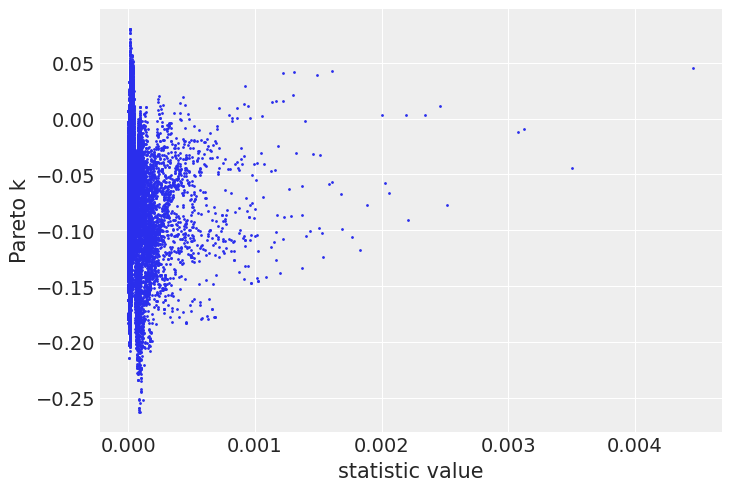

In [78]:
stat_data = _data['rh_mean_pop_weighted(1)']
stat_data = _data['t2m_max_pop_weighted(6)']
stat_data = _data['rate']

plt.scatter(stat_data, metrics['pareto_k'], s=1)
plt.xlabel('statistic value')
plt.ylabel('Pareto k')
plt.show()

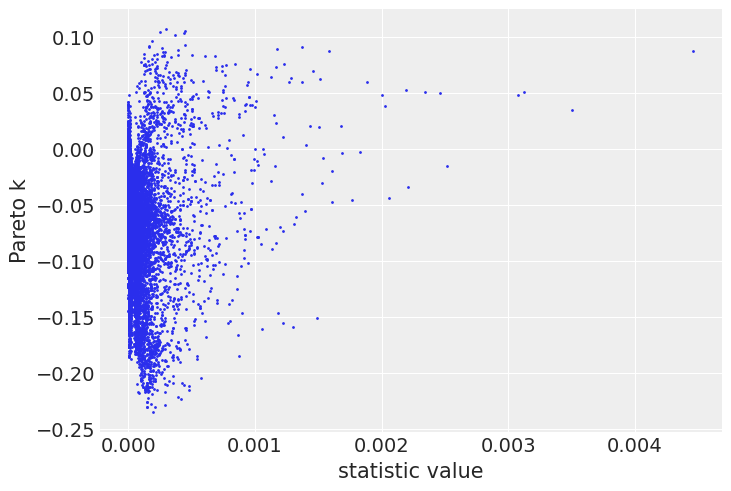

In [84]:
stat_data = _data['rh_mean_pop_weighted(1)']
stat_data = _data['t2m_max_pop_weighted(6)']
stat_data = _data['rate']

plt.scatter(stat_data, metrics['pareto_k'], s=1)
plt.xlabel('statistic value')
plt.ylabel('Pareto k')
plt.show()

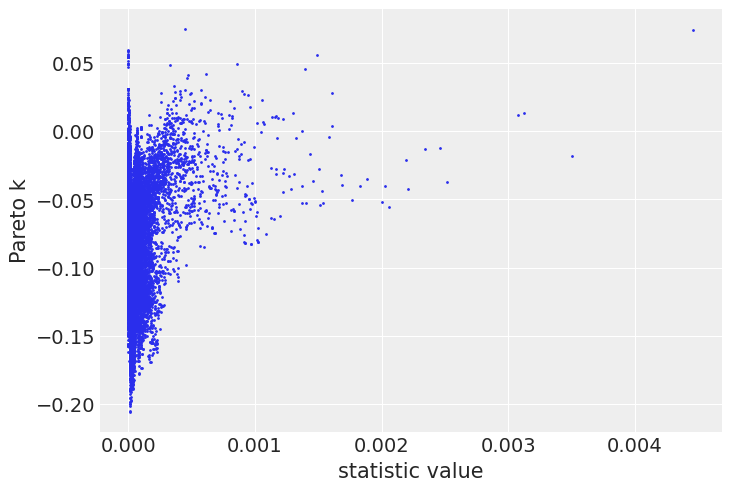

In [90]:
stat_data = _data['rh_mean_pop_weighted(1)']
stat_data = _data['t2m_max_pop_weighted(6)']
stat_data = _data['rate']

plt.scatter(stat_data, metrics['pareto_k'], s=1)
plt.xlabel('statistic value')
plt.ylabel('Pareto k')
plt.show()

---

In [35]:
pw_loo_df = _data.copy()
pw_loo_df['loo_pointwise'] = metrics['loo_pointwise']

In [42]:
f"{pw_loo_df.iloc[metrics['loo_pointwise'] < 1, :]['rate'].mean():.6f}", f"{pw_loo_df.iloc[metrics['loo_pointwise'] < -20, :]['rate'].mean():.6f}"

('0.000049', '0.000037')

In [63]:
pw_loo_df.iloc[pw_loo_df['loo_pointwise'] < -15, :][['admin2', 'rate', 'cases', 'loo_pointwise', 'population']].sort_values('rate')

,admin2,rate,cases,loo_pointwise,population
22103,TABALONG,0.001163,259.0,-16.130671,222667.0
18214,PASER,0.001168,160.0,-15.887179,136969.0
21875,SUMBA TIMUR,0.001176,328.0,-16.458082,278943.0
6424,KARANG ASEM,0.001220,614.0,-15.413829,503408.0
22102,TABALONG,0.001226,273.0,-16.739725,222667.0
18587,PENAJAM PASER UTARA,0.001267,105.0,-15.265525,82901.0
6423,KARANG ASEM,0.001307,658.0,-16.102922,503408.0
13132,KUTAI TIMUR,0.001369,341.0,-17.706572,248999.0
15621,MAPPI,0.001372,64.0,-15.468358,46647.0
17984,PANGKAJENE DAN KEPULAUAN,0.001398,403.0,-16.625091,288223.0


BOVEN DIGOEL                 5 (PAPUA)
BOLAANG MONGONDOW SELATAN    4 (south coast of North Sulawesi Province)
LAMANDAU                     3
BADUNG                       2 (Bali)
KUTAI TIMUR                  2
PASER                        2
POHUWATO                     2 (very small)
TABALONG                     2
TANA TIDUNG                  2
GIANYAR                      1 (Bali, very small and urban)
KOTA GUNUNGSITOLI            1 (very small and urban)
KUTAI BARAT                  1 (large rural)
MANGGARAI BARAT              1 ()
MAPPI                        1 (south papua)
MINAHASA UTARA               1
MOROWALI                     1
PANGKAJENE DAN KEPULAUAN     1 (very small islands)
SUMBA TIMUR                  1
WAKATOBI                     1 (small islands)

In [41]:
pw_loo_df.iloc[metrics['loo_pointwise'] < -15, :]['admin2'].value_counts()

admin2
INTAN JAYA              4
KEPAHIANG               3
BALANGAN                3
KOLAKA TIMUR            3
KLUNGKUNG               3
MALUKU TENGGARA         2
BERAU                   2
LABUHAN BATU SELATAN    2
NIAS                    2
KOTA KENDARI            2
GUNUNG KIDUL            2
JAYAWIJAYA              1
TANGGAMUS               1
KOTA GORONTALO          1
KAPUAS                  1
AGAM                    1
KAMPAR                  1
PATI                    1
PANDEGLANG              1
Name: count, dtype: int64

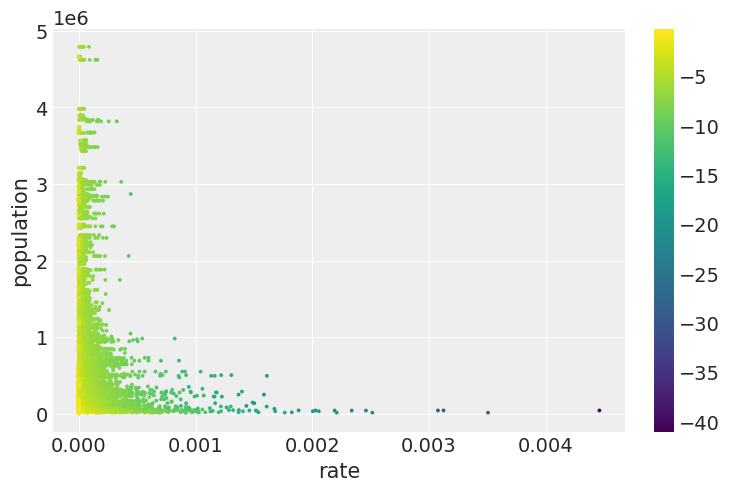

In [79]:
stat_data = _data['rh_mean_pop_weighted(1)']
stat_data = _data['t2m_max_pop_weighted(6)']
stat_data = _data['rate']
stat_data = _data['population']

mask = np.ones_like(stat_data, dtype=bool)
#mask = metrics['loo_pointwise'] < -10
#mask = _data['rate'] > 0.001
admin2 = _data['admin2'].astype('category')
codes = admin2.cat.codes
metrics['loo_pointwise'][mask]

plt.scatter(_data['rate'][mask], _data['population'][mask], s=3, c=metrics['loo_pointwise'][mask])
plt.xlabel('rate')
plt.ylabel('population')
plt.colorbar()
plt.show()

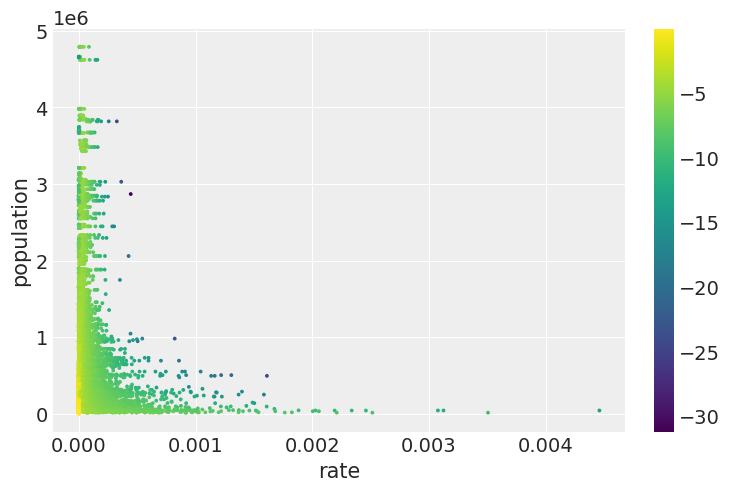

In [85]:
stat_data = _data['rh_mean_pop_weighted(1)']
stat_data = _data['t2m_max_pop_weighted(6)']
stat_data = _data['rate']
stat_data = _data['population']

mask = np.ones_like(stat_data, dtype=bool)
#mask = metrics['loo_pointwise'] < -10
#mask = _data['rate'] > 0.001
admin2 = _data['admin2'].astype('category')
codes = admin2.cat.codes
metrics['loo_pointwise'][mask]

plt.scatter(_data['rate'][mask], _data['population'][mask], s=3, c=metrics['loo_pointwise'][mask])
plt.xlabel('rate')
plt.ylabel('population')
plt.colorbar()
plt.show()

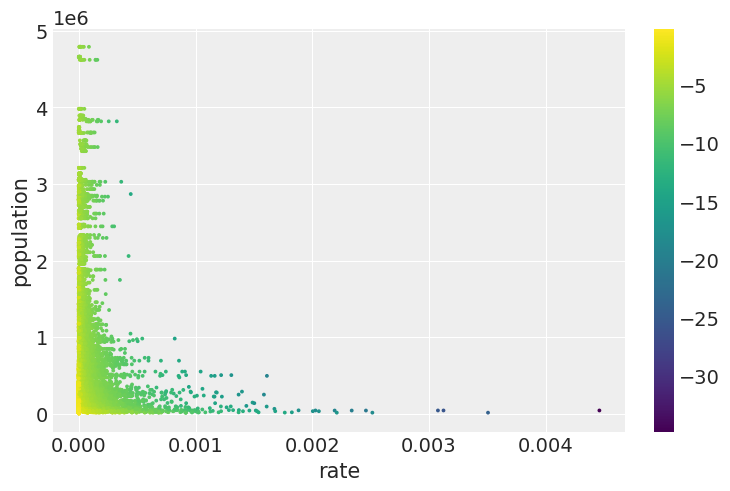

In [91]:
stat_data = _data['rh_mean_pop_weighted(1)']
stat_data = _data['t2m_max_pop_weighted(6)']
stat_data = _data['rate']
stat_data = _data['population']

mask = np.ones_like(stat_data, dtype=bool)
#mask = metrics['loo_pointwise'] < -10
#mask = _data['rate'] > 0.001
admin2 = _data['admin2'].astype('category')
codes = admin2.cat.codes
metrics['loo_pointwise'][mask]

plt.scatter(_data['rate'][mask], _data['population'][mask], s=3, c=metrics['loo_pointwise'][mask])
plt.xlabel('rate')
plt.ylabel('population')
plt.colorbar()
plt.show()

---

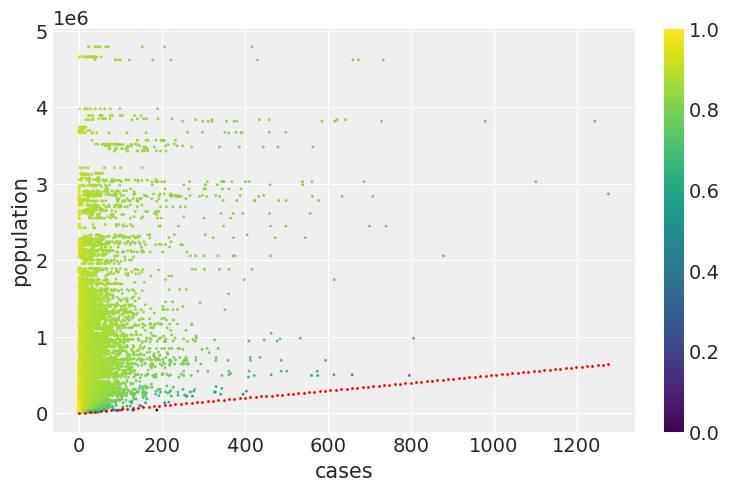

In [80]:
stat_data = _data['rh_mean_pop_weighted(1)']
stat_data = _data['t2m_max_pop_weighted(6)']
stat_data = _data['rate']
stat_data = _data['population']

mask = np.ones_like(stat_data, dtype=bool)
#mask = metrics['loo_pointwise'] < -15
admin2 = _data['admin2'].astype('category')
codes = admin2.cat.codes
metrics['loo_pointwise'][mask]

plt.scatter(_data['cases'][mask], _data['population'][mask], s=1, c=metrics['loo_pointwise'][mask])
x = np.linspace(_data['cases'][mask].min(), _data['cases'][mask].max(), 100)
plt.scatter(x, x/0.002, s=1, c='red')
plt.xlabel('cases')
plt.ylabel('population')
plt.colorbar()
plt.show()

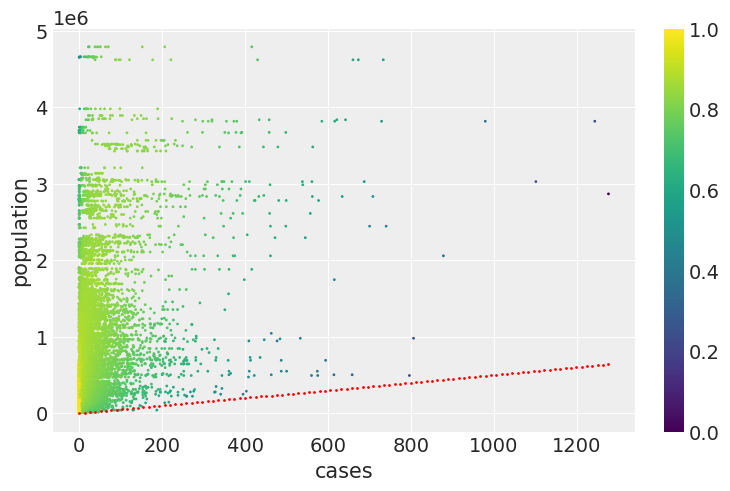

In [86]:
stat_data = _data['rh_mean_pop_weighted(1)']
stat_data = _data['t2m_max_pop_weighted(6)']
stat_data = _data['rate']
stat_data = _data['population']

mask = np.ones_like(stat_data, dtype=bool)
#mask = metrics['loo_pointwise'] < -15
admin2 = _data['admin2'].astype('category')
codes = admin2.cat.codes
metrics['loo_pointwise'][mask]

plt.scatter(_data['cases'][mask], _data['population'][mask], s=1, c=metrics['loo_pointwise'][mask])
x = np.linspace(_data['cases'][mask].min(), _data['cases'][mask].max(), 100)
plt.scatter(x, x/0.002, s=1, c='red')
plt.xlabel('cases')
plt.ylabel('population')
plt.colorbar()
plt.show()

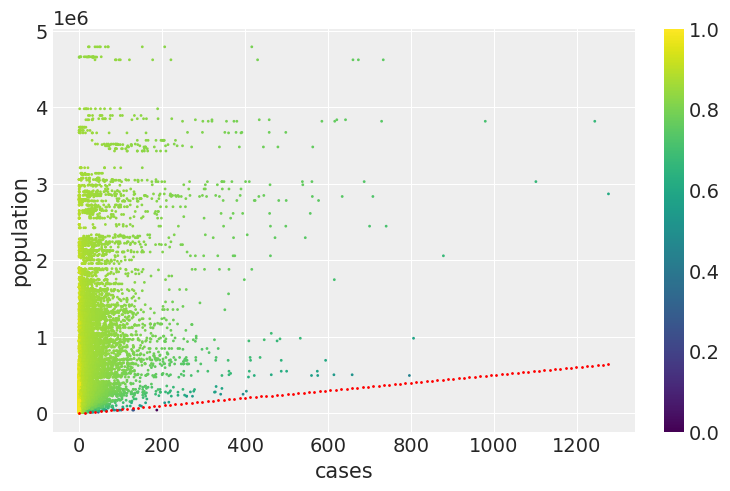

In [92]:
stat_data = _data['rh_mean_pop_weighted(1)']
stat_data = _data['t2m_max_pop_weighted(6)']
stat_data = _data['rate']
stat_data = _data['population']

mask = np.ones_like(stat_data, dtype=bool)
#mask = metrics['loo_pointwise'] < -15
admin2 = _data['admin2'].astype('category')
codes = admin2.cat.codes
metrics['loo_pointwise'][mask]

plt.scatter(_data['cases'][mask], _data['population'][mask], s=1, c=metrics['loo_pointwise'][mask])
x = np.linspace(_data['cases'][mask].min(), _data['cases'][mask].max(), 100)
plt.scatter(x, x/0.002, s=1, c='red')
plt.xlabel('cases')
plt.ylabel('population')
plt.colorbar()
plt.show()

---

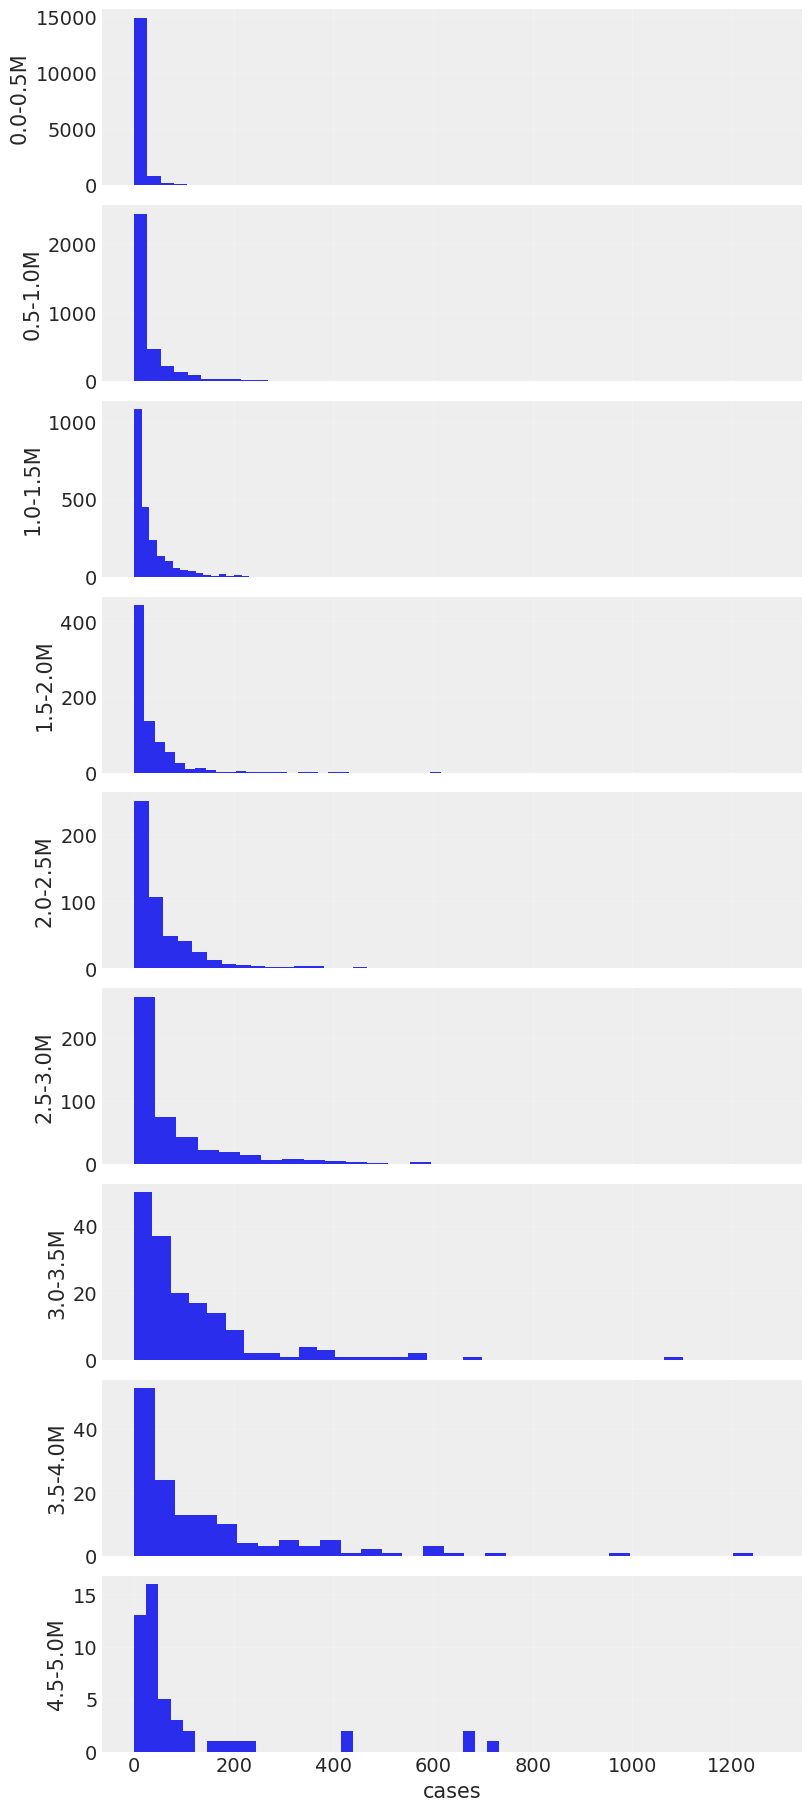

In [38]:
pop = _data['population'].values
cases = _data['cases'].values

bin_width = 500_000
bins = np.arange(0, pop.max() + bin_width, bin_width)

bin_ids = np.digitize(pop, bins) - 1

binned_cases = []
labels = []

for i in range(len(bins) - 1):
    mask = bin_ids == i
    if np.sum(mask) > 0:
        binned_cases.append(cases[mask])
        labels.append(f"{bins[i]/1e6:.1f}-{bins[i+1]/1e6:.1f}M")

fig, axes = plt.subplots(len(binned_cases), 1, figsize=(8, 2 * len(binned_cases)), sharex=True)

if len(binned_cases) == 1:
    axes = [axes]

for ax, data, label in zip(axes, binned_cases, labels):
    ax.hist(data, bins=30)
    ax.set_ylabel(label)
    ax.grid(alpha=0.2)

axes[-1].set_xlabel("cases")
plt.show()

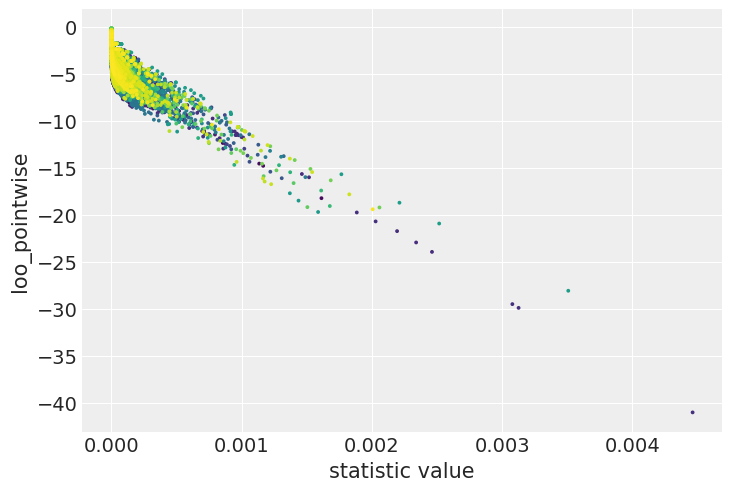

In [81]:
stat_data = _data['rh_mean_pop_weighted(1)']
#stat_data = _data['t2m_max_pop_weighted(6)']
stat_data = _data['rate']
#stat_data = _data['population']
mask = np.ones_like(stat_data, dtype=bool)
admin2 = _data['admin2'].astype('category')
codes = admin2.cat.codes

plt.scatter(stat_data[mask], metrics['loo_pointwise'][mask], s=3, c=codes[mask])
plt.xlabel("statistic value")
plt.ylabel("loo_pointwise")
plt.show()

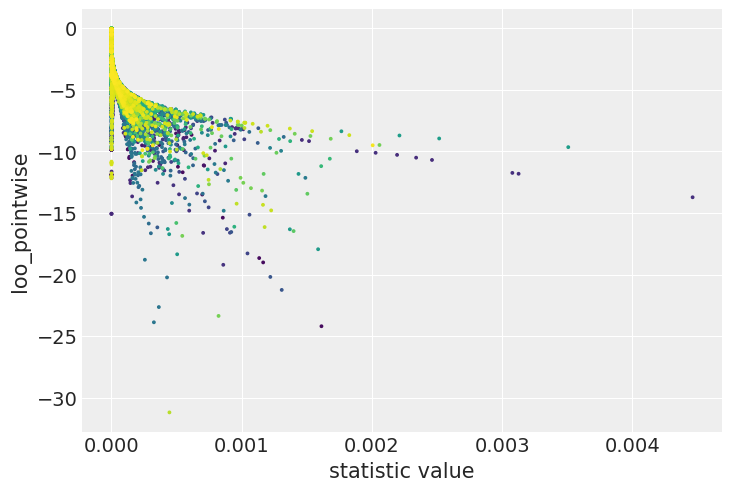

In [87]:
stat_data = _data['rh_mean_pop_weighted(1)']
#stat_data = _data['t2m_max_pop_weighted(6)']
stat_data = _data['rate']
#stat_data = _data['population']
mask = np.ones_like(stat_data, dtype=bool)
admin2 = _data['admin2'].astype('category')
codes = admin2.cat.codes

plt.scatter(stat_data[mask], metrics['loo_pointwise'][mask], s=3, c=codes[mask])
plt.xlabel("statistic value")
plt.ylabel("loo_pointwise")
plt.show()

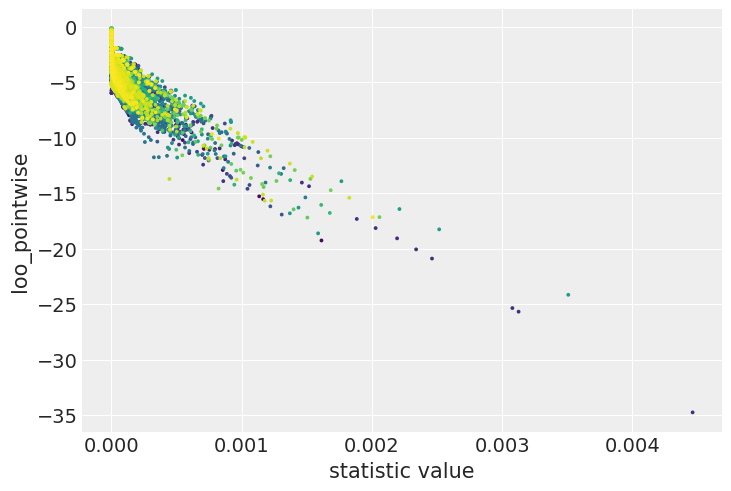

In [93]:
stat_data = _data['rh_mean_pop_weighted(1)']
#stat_data = _data['t2m_max_pop_weighted(6)']
stat_data = _data['rate']
#stat_data = _data['population']
mask = np.ones_like(stat_data, dtype=bool)
admin2 = _data['admin2'].astype('category')
codes = admin2.cat.codes

plt.scatter(stat_data[mask], metrics['loo_pointwise'][mask], s=3, c=codes[mask])
plt.xlabel("statistic value")
plt.ylabel("loo_pointwise")
plt.show()

---

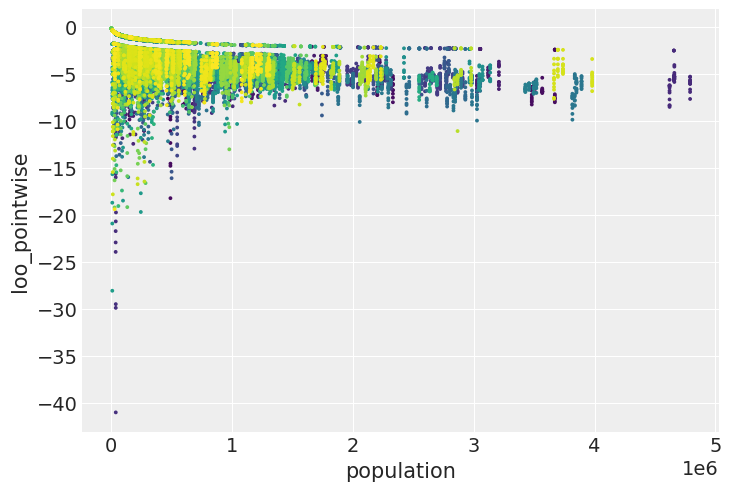

In [82]:
stat_data = _data['rh_mean_pop_weighted(1)']
stat_data = _data['t2m_max_pop_weighted(6)']
stat_data = _data['rate']
stat_data = _data['population']
mask = np.ones_like(stat_data, dtype=bool)
admin2 = _data['admin2'].astype('category')
codes = admin2.cat.codes

plt.scatter(stat_data[mask], metrics['loo_pointwise'][mask], s=3, c=codes[mask])
plt.xlabel("population")
plt.ylabel("loo_pointwise")
plt.show()

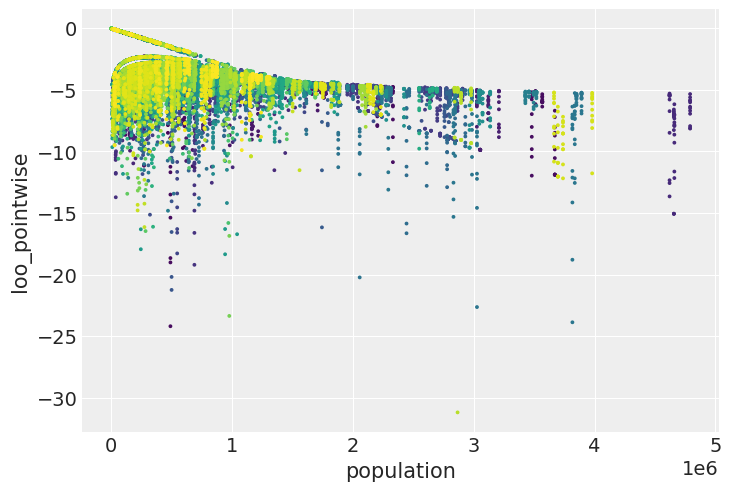

In [88]:
stat_data = _data['rh_mean_pop_weighted(1)']
stat_data = _data['t2m_max_pop_weighted(6)']
stat_data = _data['rate']
stat_data = _data['population']
mask = np.ones_like(stat_data, dtype=bool)
admin2 = _data['admin2'].astype('category')
codes = admin2.cat.codes

plt.scatter(stat_data[mask], metrics['loo_pointwise'][mask], s=3, c=codes[mask])
plt.xlabel("population")
plt.ylabel("loo_pointwise")
plt.show()

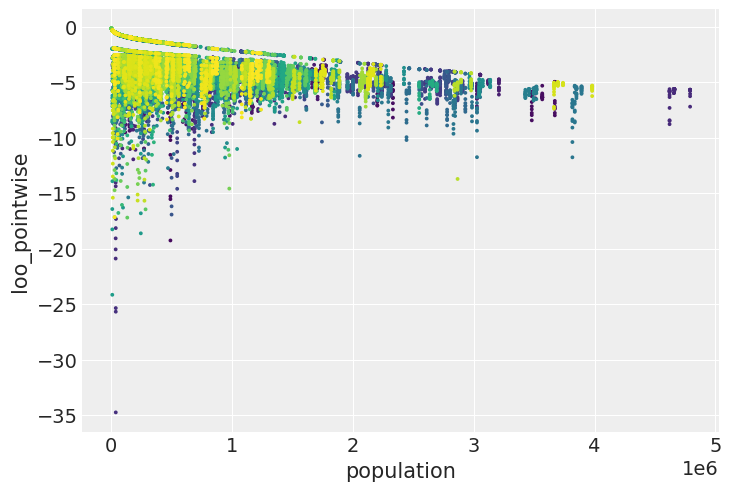

In [94]:
#stat_data = stat_data.loc[:-5, :]
stat_data = _data['rh_mean_pop_weighted(1)']
stat_data = _data['t2m_max_pop_weighted(6)']
stat_data = _data['rate']
stat_data = _data['population']
mask = np.ones_like(stat_data, dtype=bool)
admin2 = _data['admin2'].astype('category')
codes = admin2.cat.codes

plt.scatter(stat_data[mask], metrics['loo_pointwise'][mask], s=3, c=codes[mask])
plt.xlabel("population")
plt.ylabel("loo_pointwise")
plt.show()

---

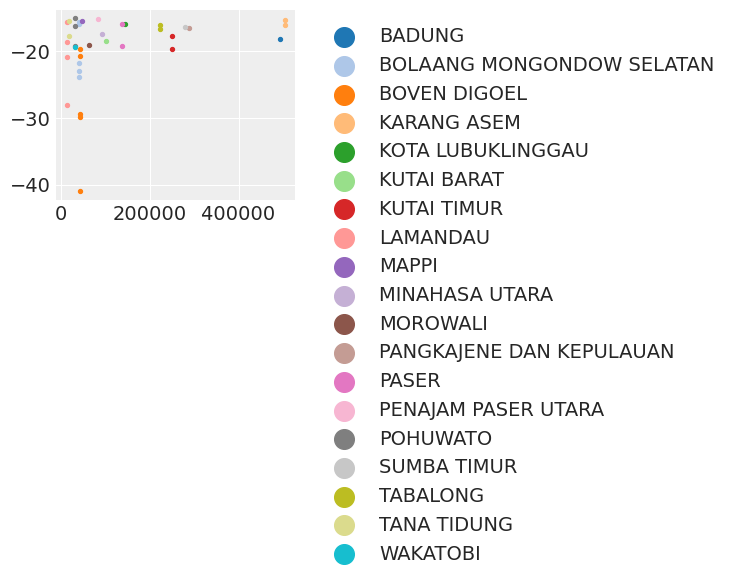

In [18]:
admin2 = _data['admin2'].astype('category')
mask = metrics['loo_pointwise'] < -15

filtered_admin2 = admin2[mask]
filtered_stat = stat_data[mask]
filtered_loo = metrics['loo_pointwise'][mask]

# Get only present categories
present_cats = filtered_admin2.unique()

cmap = plt.cm.tab20
colors = cmap(range(len(present_cats)))

for i, cat in enumerate(present_cats):
    idx = filtered_admin2 == cat
    plt.scatter(
        filtered_stat[idx],
        filtered_loo[idx],
        s=8,
        color=colors[i],
        label=cat
    )

plt.legend(markerscale=5, bbox_to_anchor=(1.05, 1))
plt.show()

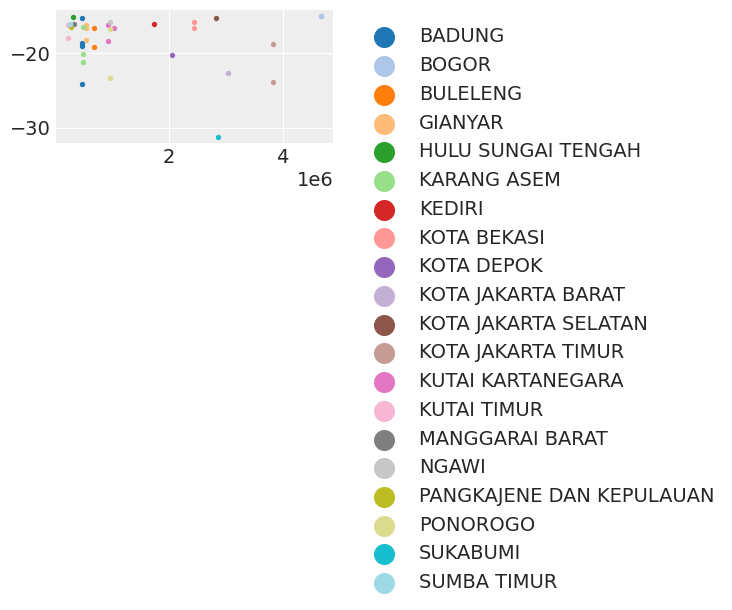

In [25]:
admin2 = _data['admin2'].astype('category')
mask = metrics['loo_pointwise'] < -15

filtered_admin2 = admin2[mask]
filtered_stat = stat_data[mask]
filtered_loo = metrics['loo_pointwise'][mask]

# Get only present categories
present_cats = filtered_admin2.unique()

cmap = plt.cm.tab20
colors = cmap(range(len(present_cats)))

for i, cat in enumerate(present_cats):
    idx = filtered_admin2 == cat
    plt.scatter(
        filtered_stat[idx],
        filtered_loo[idx],
        s=8,
        color=colors[i],
        label=cat
    )

plt.legend(markerscale=5, bbox_to_anchor=(1.05, 1))
plt.show()

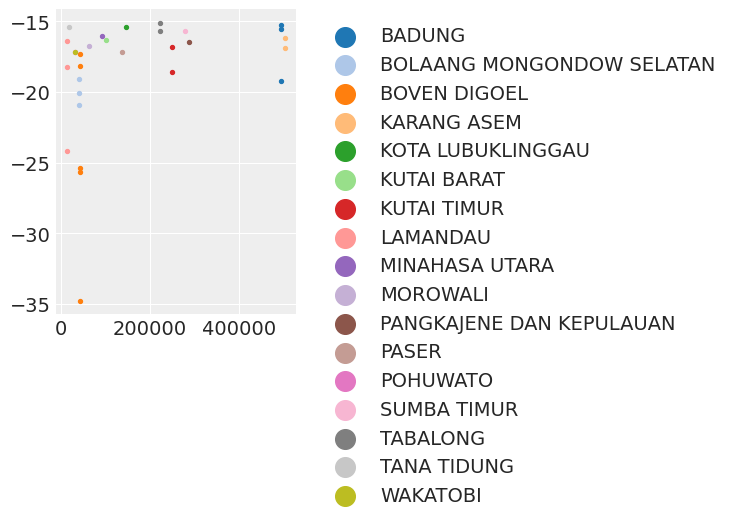

In [95]:
admin2 = _data['admin2'].astype('category')
mask = metrics['loo_pointwise'] < -15

filtered_admin2 = admin2[mask]
filtered_stat = stat_data[mask]
filtered_loo = metrics['loo_pointwise'][mask]

# Get only present categories
present_cats = filtered_admin2.unique()

cmap = plt.cm.tab20
colors = cmap(range(len(present_cats)))

for i, cat in enumerate(present_cats):
    idx = filtered_admin2 == cat
    plt.scatter(
        filtered_stat[idx],
        filtered_loo[idx],
        s=8,
        color=colors[i],
        label=cat
    )

plt.legend(markerscale=5, bbox_to_anchor=(1.05, 1))
plt.show()

In [ ]:
idata = az.from_netcdf(os.path.join(model_fits_folder, run_folders[-1], "idata", "idata_[[rh_mean_p(1)(p=2.5, 5)]+[tp_24hmean_log_p(5)(p=2.5, 5)]+[t2m_max_p(6)(p=2.5, 20)]+[tp_24hmax_log_p(2)(p=2.5, 5)]+[rh_mean_p(0)(p=2.5, 5)]].nc"))

In [ ]:
p_vals_ = [1.0]
num_knots_list_ = [5]
statistics_ = ['rh_mean_pop_weighted(0)']

p_set = set(p_vals_) if p_vals_ is not None else None
k_set = set(num_knots_list_) if num_knots_list_ is not None else None
# std_set = set(std) if std is not None else None
stat_set = set(statistics_) if statistics_ is not None else None

In [ ]:
model_settings_dict = {}
model_dict = {} 
idata_dict = {}

for stat_name in statistics_:
        for num_knots in num_knots_list_:
            for p in p_vals_:
                stat_names = [stat_name]
                abbrev_stat_names = [abbrev_stat(s) for s in stat_names]
                p_set = set([p])
                k_set = set([num_knots])
                abbrev_stat_set = set(abbrev_stat_names)
                
                settings = {
                    'alpha_type': 'exponential', 'alpha_parameters': {'lam': 0.5},
                    'intercept_type': 'normal', 'intercept_parameters': {'mu': -10.0, 'sigma': 1.0},
                    'beta_u_type': 'normal', 'beta_u_parameters': {'mu': 0, 'sigma': 1.0},
                    'link': None, 'link_stat_name': None, 'link_type': None,
                    'b1_type': None, 'b1_parameters': None,
                    'c_type': None, 'c_parameters': None,
                    'stat_names': stat_names, 'num_knots': num_knots, 'knot_type': 'equispaced', 'degree': 3,
                    'spline_implementation': 'svd', 'spline_type': 'halfnormal', 'spline_parameters': {'sigma_w_sigma': 10.0},
                    'penalty_order': 2, 'penalty_type': 'halfnormal', 'penalty_parameters': {'p': p}, 'penalty_std': False,
                    'cutoff': None,
                    'exclude': ['intercept', 'beta_u', 'alpha', 'zi_b1', 'zi_c'],
                    'surveillance_name': None,
                    'urbanisation_name': 'urbanisation_pop_weighted_std'}
                
                model_name = build_model_name(settings['alpha_type'], settings['alpha_parameters'],
                                settings['intercept_type'], settings['intercept_parameters'],
                                settings['link'], settings['link_stat_name'], settings['link_type'],
                                settings['b1_type'], settings['b1_parameters'],
                                settings['c_type'], settings['c_parameters'],
                                settings['stat_names'], settings['num_knots'], settings['knot_type'], settings['degree'],
                                settings['spline_implementation'], settings['spline_type'], settings['spline_parameters'],
                                settings['penalty_order'], settings['penalty_type'], settings['penalty_parameters'], settings['penalty_std'],
                                settings['cutoff'], settings['beta_u_type'], settings['beta_u_parameters'],
                                exclude=settings['exclude'],
                                surveillance_name=settings['surveillance_name'],
                                urbanisation_name=settings['urbanisation_name'])
                model_settings_dict[model_name] = settings

                model, m, B, knot_list = build_sig_spline_p_model(_data.copy(), **settings)
                model_dict[model_name] = model

                found = 0
                for run in run_folders:
                    idata_dir = os.path.join(model_fits_folder, run, 'idata')
                    # print(idata_dir)
                    if not os.path.isdir(idata_dir):
                        continue
                    for fname in os.listdir(idata_dir):
                        if not fname.endswith('.nc'):
                            continue
                        meta = parse_name(fname)
                        if p_set is not None and meta['p'] not in p_set:
                            continue
                        if k_set is not None and meta['num_knots'] not in k_set:
                            continue
                        # if std_set is not None and meta['std'] not in std_set:
                            # continue
                        if stat_set is not None and meta['stat_name'] not in abbrev_stat_set:
                            continue
                        # print(meta['p'], meta['num_knots'], meta['stat_name'])

                        idata_ = az.from_netcdf(os.path.join(idata_dir, fname))
                        idata_dict[model_name] = idata_
                        found = 1
                if found==0:
                    raise ValueError("No models matched the given filters.")

In [ ]:
for m in model_dict:
    print(m)
    model = model_dict[m]
    idata = idata_dict.get(m)

    # Tile the posterior draws N times
    N = 10  # multiplier — gives you N × original draws
    idata_tiled = idata.copy()
    idata_tiled.posterior = idata.posterior.isel(
        draw=np.tile(np.arange(idata.posterior.dims["draw"]), N)
    )
    with model:
        posterior_predictive = pm.sample_posterior_predictive(idata_tiled).posterior_predictive

In [ ]:

obs = idata.observed_data['y_obs'].values
ppc = posterior_predictive['y_obs'].values
ppc = ppc.reshape(-1, 24107).T
ppc_mean = np.mean(ppc, axis=1)
ppc_median = np.median(ppc, axis=1)
ppc_hdi = {}
coverage = {}
for q in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]:
    ppc_hdi[q] = az.hdi(ppc.T, hdi_prob=q)
    coverage[q] = np.mean((obs >= ppc_hdi[q][:, 0]) & (obs <= ppc_hdi[q][:, 1]))
    print(f'{q*100:.0f}% HDI Coverage: {coverage[q]}')

In [ ]:
plt.plot(coverage.keys(), coverage.values())
plt.plot([0, 1], [0, 1], '--', lw=0.8, color='tomato')
plt.show()

In [ ]:
data_ppc = _data.copy()
data_ppc['ppc'] = [ppc[i, :] for i in range(ppc.shape[0])]
data_ppc['ppc_mean'] = ppc_mean
data_ppc['ppc_median'] = ppc_median
data_ppc['ppc_hdi_1-q'] = ppc_hdi[:, 0]
data_ppc['ppc_hdi_q'] = ppc_hdi[:, 1]

data_ppc['ppc_mean_rate'] = data_ppc['ppc_mean']/data_ppc['population']
data_ppc['ppc_median_rate'] = data_ppc['ppc_median']/data_ppc['population']
data_ppc['ppc_hdi_1-q_rate'] = data_ppc['ppc_hdi_1-q']/data_ppc['population']
data_ppc['ppc_hdi_q_rate'] = data_ppc['ppc_hdi_q']/data_ppc['population']

In [ ]:
data_ppc = data_ppc.iloc[data_ppc['admin1']=='ACEH']
print(np.mean((data_ppc['rate'] >= data_ppc['ppc_hdi_1-q_rate']) & (data_ppc['rate'] <= data_ppc['ppc_hdi_q_rate'])))
data_ppc.sort_values(by='rh_mean_pop_weighted(0)', inplace=True)

idx = np.arange(len(data_ppc))

fig, ax = plt.subplots(figsize=(14, 5))

# HDI band
ax.fill_between(idx, data_ppc['ppc_hdi_1-q_rate'], data_ppc['ppc_hdi_q_rate'], alpha=0.3, color='steelblue', label=f'{q*100:.0f}% HDI')

# PPC mean and observed
ax.scatter(idx, data_ppc['ppc_mean_rate'], s=0.1, color='steelblue', label='PPC mean')
ax.scatter(idx, data_ppc['ppc_median_rate'], s=0.1, color='lightsteelblue', label='PPC median')
ax.scatter(idx, data_ppc['rate'], s=0.1, color='tomato', label='Observed')

ax.legend()
ax.set_xlabel('Index')
ax.set_ylabel('y_obs')
ax.set_ylim(0, 0.001)
plt.show()

In [ ]:
idx = np.arange(len(obs))

fig, ax = plt.subplots(figsize=(14, 5))

# HDI band
ax.fill_between(idx, data_ppc['ppc_hdi_5%'], data_ppc['ppc_hdi_95%'], alpha=0.3, color='steelblue', label='90% HDI')

# PPC mean and observed
ax.scatter(idx, data_ppc['ppc_mean'], s=2, color='steelblue', label='PPC mean')
ax.scatter(idx, obs, s=2, color='tomato', label='Observed')

ax.legend()
ax.set_xlabel('Index')
ax.set_ylabel('y_obs')
plt.show()

In [ ]:
data_ppc = _data.copy()
data_ppc['ppc'] = [ppc[i, :] for i in range(ppc.shape[0])]

In [ ]:
data_ppc['ppc_mean'] = data_ppc['ppc'].apply(lambda x: np.mean(x))
data_ppc['ppc_hdi_5%'] = data_ppc['ppc'].apply(lambda x: az.hdi(x, hdi_prob=0.95)[0])

In [ ]:
data_ppc['ppc_hdi_5%']

---

In [ ]:
model_settings_dict = {}
model_dict = {} 
for stat_name in statistics_:
        for num_knots in num_knots_list_:
            for p in p_vals_:
                stat_names = [stat_name]
                settings = {
                    'alpha_type': 'exponential', 'alpha_parameters': {'lam': 0.5},
                    'intercept_type': 'normal', 'intercept_parameters': {'mu': -10.0, 'sigma': 1.0},
                    'beta_u_type': 'normal', 'beta_u_parameters': {'mu': 0, 'sigma': 1.0},
                    'link': None, 'link_stat_name': None, 'link_type': None,
                    'b1_type': None, 'b1_parameters': None,
                    'c_type': None, 'c_parameters': None,
                    'stat_names': stat_names, 'num_knots': num_knots, 'knot_type': 'equispaced', 'degree': 3,
                    'spline_implementation': 'svd', 'spline_type': 'halfnormal', 'spline_parameters': {'sigma_w_sigma': 10.0},
                    'penalty_order': 2, 'penalty_type': 'halfnormal', 'penalty_parameters': {'p': p}, 'penalty_std': False,
                    'cutoff': None,
                    'exclude': ['intercept', 'beta_u', 'alpha', 'zi_b1', 'zi_c'],
                    'surveillance_name': None,
                    'urbanisation_name': 'urbanisation_pop_weighted_std'}
                
                model_name = build_model_name(settings['alpha_type'], settings['alpha_parameters'],
                                settings['intercept_type'], settings['intercept_parameters'],
                                settings['link'], settings['link_stat_name'], settings['link_type'],
                                settings['b1_type'], settings['b1_parameters'],
                                settings['c_type'], settings['c_parameters'],
                                settings['stat_names'], settings['num_knots'], settings['knot_type'], settings['degree'],
                                settings['spline_implementation'], settings['spline_type'], settings['spline_parameters'],
                                settings['penalty_order'], settings['penalty_type'], settings['penalty_parameters'], settings['penalty_std'],
                                settings['cutoff'], settings['beta_u_type'], settings['beta_u_parameters'],
                                exclude=settings['exclude'],
                                surveillance_name=settings['surveillance_name'],
                                urbanisation_name=settings['urbanisation_name'])
                model_settings_dict[model_name] = settings

                model, m, B, knot_list = build_sig_spline_p_model(_data.copy(), **settings)
                model_dict[model_name] = model

In [ ]:
idata_dict = {}
for stat_name in [abbrev_stat(s) for s in statistics_]:
        # print(stat_name, '\n')
        for num_knots in num_knots_list_:
            for p in p_vals_:
                stat_names = [stat_name]
                stat_set = set(stat_names) if stat_names is not None else None
                found = 0
                for run in run_folders:
                    idata_dir = os.path.join(model_fits_folder, run, 'idata')
                    # print(idata_dir)
                    if not os.path.isdir(idata_dir):
                        continue
                    for fname in os.listdir(idata_dir):
                        if not fname.endswith('.nc'):
                            continue
                        meta = parse_name(fname)
                        if p_set is not None and meta['p'] not in p_set:
                            continue
                        if k_set is not None and meta['num_knots'] not in k_set:
                            continue
                        # if std_set is not None and meta['std'] not in std_set:
                            # continue
                        if stat_set is not None and meta['stat_name'] not in stat_set:
                            continue
                        # print(meta['p'], meta['num_knots'], meta['stat_name'])

                        idata = az.from_netcdf(os.path.join(idata_dir, fname))
                        idata_dict[fname] = idata
                        found = 1
                if found==0:
                    raise ValueError("No models matched the given filters.")

In [ ]:
for m in model_dict:
    print(m)
    model = model_dict[m]
    idata = idata_dict.get(m + '.nc', None)

In [ ]:
model_fits_dir = model_fits_folder
metric_files = []
for run in run_folders:
    metrics_dir = os.path.join(model_fits_dir, run, 'metrics')
    if not os.path.isdir(metrics_dir):
        continue
    for fname in os.listdir(metrics_dir):
        if not fname.endswith('.npz'):
            continue
        meta = parse_name(fname)
        if p_set is not None and meta['p'] not in p_set:
            continue
        if k_set is not None and meta['num_knots'] not in k_set:
            continue
        # if std_set is not None and meta['std'] not in std_set:
            # continue
        if stat_set is not None and meta['stat_name'] not in stat_set:
            continue
        metric_files.append(os.path.join(metrics_dir, fname))

if not metric_files:
    raise ValueError("No models matched the given filters.")

In [ ]:
metric_files

In [ ]:
np.load(metric_files[0]).files